# E62 · When the model cannot answer: unidentified parts, intractable models, and keeping the answer on the question

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Three real datasets, one per failure: a US apparel brand in Conjura's open e-commerce MMM dataset (Anderson 2024, CC BY 4.0; 147 weeks of new customers and Google + Meta spend) · Capital Bikeshare hourly rentals, Washington DC 2011-2012 (Fanaee-T & Gama 2013; 17,379 hours) · the AIDS Clinical Trials Group Study 175 (Hammer et al. 1996; 2,139 patients, time to AIDS, death or a 50% CD4 drop) |
| **You will learn** | How to write down the question **before** the model (a *question contract*: quantity, population, scale, decision) · why a clean fit (r_hat 1.00, zero divergences, narrow intervals) says nothing about whether the data answer your question · **prior swapping** as the test for an unidentified quantity, and why prior-to-posterior contraction can fool you · structural non-identifiability that no prior fixes (baseline vs media) and why LOO cannot settle it · a **fake-data check** that separates "the model is wrong" from "the data cannot tell" · the value of an experiment · **pricing a model before running it**: timing one gradient, the $O(n^3)$ wall, and choosing between approximating the model, shrinking the data to the question's resolution, and shrinking the question · **validating an approximation where the exact model is still feasible** · hazard ratio vs risk difference vs the clinic's own population: three true numbers, one of which answers the question · ranking questions the data cannot support, and the smaller question they can · an **answer audit** |

Most failed analyses do not crash. They finish, print tidy numbers, and answer a question that
nobody asked, or answer the right question with numbers that came from the prior, or never
finish at all because the model was too big. This notebook takes three real problems, lets each
fail in its typical way, and shows how to notice and what to do next.

| failure | what it looks like | how to see it | pivots |
|---|---|---|---|
| **Unidentified components** (part A) | a model that fits well and reports a confident answer that the data never saw | swap the prior and watch the answer move; fake-data recovery | answer a combination the data do identify; add information (an experiment, a prior from one); answer the decision instead of the parameter |
| **Computationally too complex** (part B) | a fit that would take months, or memory that runs out | time one gradient on small subsets and extrapolate before sampling | approximate the model; shrink the data to the resolution the question needs; shrink the question |
| **Answer drifts from the question** (part C) | a correct number on the wrong scale, population or contrast; a ranking the data cannot support | write the question contract first; audit the answer against it | compute the asked quantity from the posterior; move to the nearest question the data can answer, and say so |

The common tool is a **question contract**, written before any model: *what quantity, for which
population, on which scale, to inform which decision*. At the end of each part we compare what
was asked with what was answered.

In [1]:
import logging
import time
import warnings
from dataclasses import dataclass

import arviz as az
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from IPython.display import display

from pymc_challenges import data

RANDOM_SEED = 62
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # many small fits: no sampler banner each
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")  # NaN r_hat of constants
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## The question contract

A small record we fill in before modelling and check against at the end. "Decision" matters
most: it tells you how precise the answer has to be, and often lets you answer a smaller
question that still settles the decision.

In [2]:
@dataclass
class Question:
    asked: str        # the question in the stakeholder's words
    quantity: str     # the number that answers it
    population: str   # for whom / over what period
    scale: str        # units: absolute, relative, per 100, per $1000...
    decision: str     # what will be done with the answer

    def show(self):
        for k, v in self.__dict__.items():
            print(f"{k:>10}: {v}")


def q(x, probs=(0.05, 0.5, 0.95)):
    """Posterior quantiles of a 1-D array of draws, rounded for printing."""
    return np.round(np.quantile(x, probs), 2)

---
# Part A · Unidentified components: which channel works better?

## A1 · The question

The marketing lead of a US apparel brand spends on Google (search, shopping, Performance Max)
and Meta (Facebook, Instagram), about $22k a week together. They ask:

In [3]:
QA = Question(
    asked="Which channel brings more new customers per dollar, Google or Meta? "
          "Where should next quarter's extra budget go?",
    quantity="ROI of each channel: incremental new customers per $1000, and their difference",
    population="this brand, Aug 2021 - May 2024, at the spend levels it actually ran",
    scale="new customers per $1000 (CAC = 1000 / ROI dollars)",
    decision="shift budget between Google and Meta",
)
QA.show()

     asked: Which channel brings more new customers per dollar, Google or Meta? Where should next quarter's extra budget go?
  quantity: ROI of each channel: incremental new customers per $1000, and their difference
population: this brand, Aug 2021 - May 2024, at the spend levels it actually ran
     scale: new customers per $1000 (CAC = 1000 / ROI dollars)
  decision: shift budget between Google and Meta


conjura_mmm: 132,759 brand x territory x day rows (143 anonymised series from 93 e-commerce brands, 2019-2024): first-time and all purchases (orders, units, original price, discount), and spend / clicks / impressions for Google (search, shopping, PMax, display, video), Meta (Facebook, Instagram, other) and TikTok, plus organic/direct/email/referral clicks. Missing spend means the brand did not use that channel.
  source: Anderson, A. (2024), Multi-Region Marketing Mix Modelling (MMM) Dataset for Several eCommerce Brands, Conjura, figshare, doi:10.6084/m9.figshare.25314841 (CC BY 4.0).
  url:    https://ndownloader.figshare.com/files/46779652


Apparel, USD, 147 full weeks 2021-08-01 -> 2024-05-19
weeks with zero spend (Google, Meta): 0 0
TikTok spend over the whole period: $8,799 (ignored)
correlation of weekly spend: 0.89 (log scale 0.82)


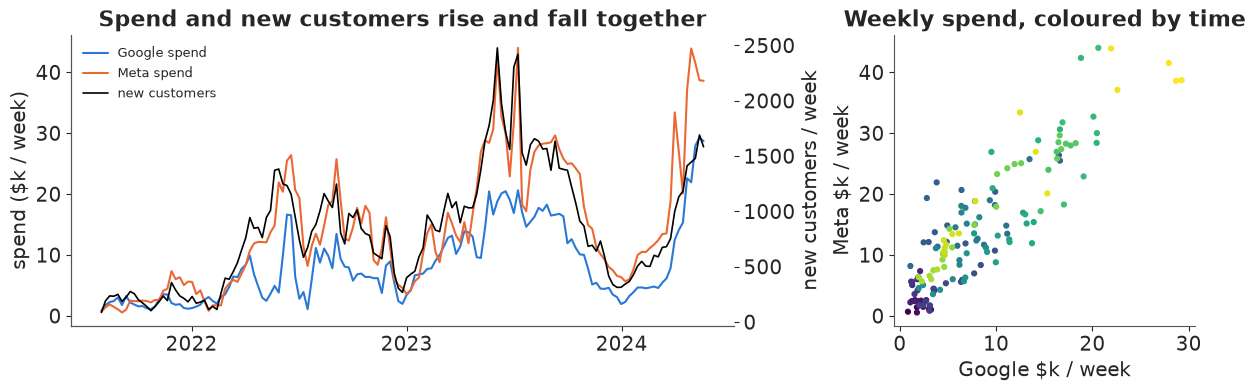

In [4]:
data.describe("conjura_mmm")
raw = data.load("conjura_mmm")
d = raw[raw["MMM_TIMESERIES_ID"].str.startswith("f7493de0")].copy()
d["date"] = pd.to_datetime(d["DATE_DAY"])
spend_cols = [c for c in d.columns if c.endswith("_SPEND")]
d[spend_cols] = d[spend_cols].fillna(0)  # NaN spend = channel not used (dataset documentation)
d["google"] = d[[c for c in spend_cols if c.startswith("GOOGLE")]].sum(axis=1)
d["meta"] = d[[c for c in spend_cols if c.startswith("META")]].sum(axis=1)
daily = d.set_index("date").sort_index()
wk = daily[["FIRST_PURCHASES", "google", "meta"]].resample("W-SUN").sum()
wk = wk[daily["FIRST_PURCHASES"].resample("W-SUN").count() == 7]  # full weeks only
tiktok = daily["TIKTOK_SPEND"].sum()
vertical, currency = d["ORGANISATION_VERTICAL"].iloc[0], d["CURRENCY_CODE"].iloc[0]
del raw, d, daily  # the full 132k-row table is no longer needed
print(f"{vertical}, {currency}, {len(wk)} full weeks "
      f"{wk.index.min().date()} -> {wk.index.max().date()}")
print("weeks with zero spend (Google, Meta):", int((wk.google == 0).sum()), int((wk.meta == 0).sum()))
print(f"TikTok spend over the whole period: ${tiktok:,.0f} (ignored)")
print(f"correlation of weekly spend: {np.corrcoef(wk.google, wk.meta)[0, 1]:.2f} "
      f"(log scale {np.corrcoef(np.log(wk.google), np.log(wk.meta))[0, 1]:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), width_ratios=[2.2, 1])
ax2 = axes[0].twinx()
axes[0].plot(wk.index, wk.google / 1e3, color=BLUE, label="Google spend")
axes[0].plot(wk.index, wk.meta / 1e3, color=ORANGE, label="Meta spend")
ax2.plot(wk.index, wk.FIRST_PURCHASES, color="k", lw=1.2, label="new customers")
axes[0].set(ylabel="spend ($k / week)", title="Spend and new customers rise and fall together")
ax2.set_ylabel("new customers / week")
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
h1, l1 = axes[0].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[0].legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)
axes[1].scatter(wk.google / 1e3, wk.meta / 1e3, s=12, c=np.arange(len(wk)), cmap="viridis")
axes[1].set(xlabel="Google $k / week", ylabel="Meta $k / week", title="Weekly spend, coloured by time");

The two channels' spend moves together (correlation about 0.9): the brand scales both up in
the summer and down in winter. That is the setting in which a regression has trouble telling
two causes apart. New customers also grew about tenfold over the period, as did spend, which
will matter in section A5.

## A2 · A standard MMM

The usual structure: new customers $y_t \sim \text{NegBinomial}(\mu_t, \alpha)$ with

$$\mu_t = \underbrace{\exp(b_0 + b_1 t + \text{Fourier}_t)}_{\text{baseline}} +
  \sum_{c \in \{G, M\}} \beta_c \left(1 - e^{-\lambda_c a_{ct}}\right),$$

where $a_{ct}$ is spend (in units of the channel's average week) carried over with a
geometric adstock of rate $\theta_c$ over 6 weeks, $\beta_c$ is the channel's maximum weekly
contribution and $\lambda_c$ its saturation rate. The question's quantities are deterministic
functions: ROI per channel (customers per $1000 over the period), their sum over both channels
(`roi_total`), and the **marginal** return of spending 10% more on both channels in the
historical mix (`mroi`). The builder takes the prior scale of $\beta$ and the baseline type as
arguments, because we will vary both.

In [5]:
y = wk["FIRST_PURCHASES"].to_numpy()
X = wk[["google", "meta"]].to_numpy()
T = len(y)
L_ADSTOCK = 6
Xs = X / X.mean(axis=0)
lags = np.zeros((T, 2, L_ADSTOCK))  # lags[t, c, l] = scaled spend of channel c at week t - l
for lag in range(L_ADSTOCK):
    lags[lag:, :, lag] = Xs[: T - lag]
tt = np.arange(T) / 52.0
doy = wk.index.dayofyear.to_numpy() / 365.25
fourier = np.column_stack([f(2 * np.pi * k * doy) for f in (np.sin, np.cos) for k in (1, 2)])
coords_a = {"week": wk.index, "channel": ["google", "meta"], "fourier": np.arange(4)}


def build_mmm(beta_sd=(600.0, 600.0), baseline="linear", y_obs=y, lift=None):
    """MMM; lift = (channel index, observed ROI, its standard error) adds an experiment."""
    with pm.Model(coords=coords_a) as m:
        theta = pm.Beta("theta", 2, 2, dims="channel")
        w = (1 - theta)[:, None] * theta[:, None] ** np.arange(L_ADSTOCK)
        a = (lags * (w / w.sum(axis=1, keepdims=True))[None]).sum(axis=-1)  # (week, channel)
        lam = pm.Gamma("lam", 2, 2, dims="channel")
        beta = pm.HalfNormal("beta", sigma=np.asarray(beta_sd), dims="channel")
        contrib = pm.Deterministic("contrib", beta * (1 - pt.exp(-lam * a)), dims=("week", "channel"))
        contrib_up = beta * (1 - pt.exp(-lam * 1.1 * a))  # both channels +10%
        b0 = pm.Normal("b0", np.log(300), 1)
        g = pm.Normal("g", 0, 0.3, dims="fourier")
        if baseline == "linear":
            level = pm.Normal("b1", 0, 0.5) * tt
        else:  # random walk in steps of 4 weeks
            s_rw = pm.HalfNormal("s_rw", 0.1)
            z = pm.Normal("z_rw", 0, 1, shape=T // 4 + 1)
            level = pt.cumsum(s_rw * z)[np.arange(T) // 4]
        base = pm.Deterministic("base", pt.exp(b0 + level + fourier @ g), dims="week")
        alpha = pm.Gamma("alpha", 2, 0.1)
        pm.NegativeBinomial("y", mu=base + contrib.sum(axis=1), alpha=alpha, observed=y_obs,
                            dims="week")
        roi = pm.Deterministic("roi", 1000 * contrib.sum(axis=0) / X.sum(axis=0), dims="channel")
        pm.Deterministic("roi_diff", roi[0] - roi[1])
        pm.Deterministic("roi_total", 1000 * contrib.sum() / X.sum())
        pm.Deterministic("mroi", 1000 * (contrib_up.sum() - contrib.sum()) / (0.1 * X.sum()))
        if lift is not None:
            ch, obs, se = lift
            pm.Normal("lift_test", mu=roi[ch], sigma=se, observed=obs)
    return m


KEEP = ["theta", "lam", "beta", "b0", "alpha", "roi", "roi_diff", "roi_total", "mroi"]
t0 = time.perf_counter()
with build_mmm() as mmm:
    idata_a = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    prior_a = pm.sample_prior_predictive(4000, random_seed=RANDOM_SEED)
print(f"fit in {time.perf_counter() - t0:.0f} s; divergences: "
      f"{int(idata_a.sample_stats['diverging'].sum())}; nutpie warm-up "
      f"{idata_a.posterior.attrs.get('tuning_steps')} steps")
az.summary(idata_a, var_names=KEEP, round_to=3)

fit in 4 s; divergences: 0; nutpie warm-up 400 steps


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
theta[google],0.320,0.135,0.110,0.540,3875.534,2672.687,1.000,0.002,0.002
theta[meta],0.116,0.069,0.026,0.244,5024.980,2403.048,1.000,0.001,0.001
lam[google],0.350,0.088,0.223,0.504,1079.135,1558.352,1.001,0.003,0.002
lam[meta],0.354,0.083,0.237,0.498,1184.831,1523.880,1.003,0.002,0.002
beta[google],1293.398,297.027,862.817,1810.742,1056.397,1400.339,1.005,9.008,5.918
beta[meta],1421.028,298.579,985.534,1939.490,1118.269,1479.036,1.004,8.855,5.905
b0,3.981,0.204,3.633,4.286,2695.931,2518.882,1.001,0.004,0.003
alpha,30.241,4.064,24.020,37.066,5098.883,3200.210,1.000,0.057,0.065
roi[google],40.210,5.124,32.124,48.280,2385.867,2682.686,1.002,0.105,0.087
roi[meta],26.234,3.014,21.446,30.929,2494.143,2182.428,1.001,0.060,0.050


Everything a checklist asks for is here: r_hat 1.00, thousands of effective draws, zero
divergences. And the answer to the question looks crisp:

In [6]:
roi_a = az.extract(idata_a, var_names=["roi"]).values  # (channel, sample)
print("ROI Google  (customers per $1000):", q(roi_a[0]))
print("ROI Meta                         :", q(roi_a[1]))
print(f"P(Google ROI > Meta ROI) = {(roi_a[0] > roi_a[1]).mean():.3f}")

ROI Google  (customers per $1000): [31.84 40.17 48.55]
ROI Meta                         : [21.26 26.22 31.08]
P(Google ROI > Meta ROI) = 0.967


"Google is about 1.5 times as efficient, probability 0.97: move budget to Google." Before
anyone acts on this, the question is **where that confidence came from**.

## A3 · First symptom: the posterior is a ridge

Plot the two ROIs against each other. If the data told the channels apart, the cloud would be
round. Here it is a long diagonal streak: what the data pin down is roughly a weighted *sum*
of the two channels, and draws trade Google for Meta along the streak.

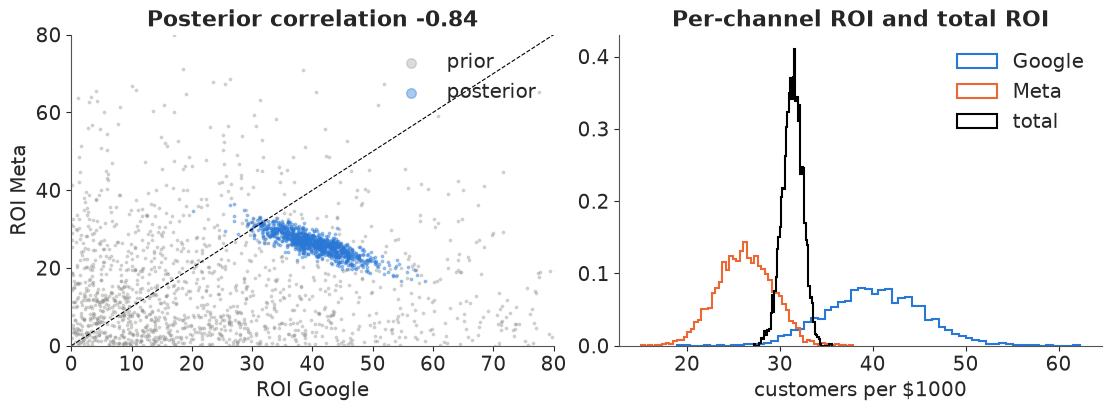

In [7]:
roi_p = prior_a.prior["roi"].values.reshape(-1, 2)
tot_a = az.extract(idata_a, var_names=["roi_total"]).values
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(roi_p[:1500, 0], roi_p[:1500, 1], s=3, color=GREY, alpha=0.3, label="prior")
axes[0].scatter(roi_a[0, ::4], roi_a[1, ::4], s=3, color=BLUE, alpha=0.4, label="posterior")
axes[0].plot([0, 80], [0, 80], color="k", lw=0.8, ls="--")
axes[0].set(xlim=(0, 80), ylim=(0, 80), xlabel="ROI Google", ylabel="ROI Meta",
            title=f"Posterior correlation {np.corrcoef(roi_a)[0, 1]:.2f}")
axes[0].legend(markerscale=4)
for x_, col, lab in [(roi_a[0], BLUE, "Google"), (roi_a[1], ORANGE, "Meta"), (tot_a, "k", "total")]:
    axes[1].hist(x_, bins=60, density=True, histtype="step", color=col, lw=1.5, label=lab)
axes[1].set(xlabel="customers per $1000", title="Per-channel ROI and total ROI")
axes[1].legend();

A common first reaction is to measure how much each quantity learned from the data, the
**contraction** $1 - \mathrm{var}_\text{post} / \mathrm{var}_\text{prior}$ (1 = the data decided
it, 0 = the posterior is the prior).

In [8]:
def contraction(prior_draws, post_draws):
    return 1 - np.var(post_draws) / np.var(prior_draws)


pri = {k: prior_a.prior[k].values.reshape(-1, *prior_a.prior[k].shape[2:]) for k in
       ["roi", "roi_diff", "roi_total", "mroi"]}
post = {k: az.extract(idata_a, var_names=[k]).values for k in ["roi_diff", "roi_total", "mroi"]}
print(pd.Series({
    "ROI Google": contraction(pri["roi"][:, 0], roi_a[0]),
    "ROI Meta": contraction(pri["roi"][:, 1], roi_a[1]),
    "ROI Google - Meta": contraction(pri["roi_diff"], post["roi_diff"]),
    "ROI total": contraction(pri["roi_total"], post["roi_total"]),
    "marginal ROI (+10%)": contraction(pri["mroi"], post["mroi"]),
}, name="contraction").round(3).to_string())

ROI Google             0.957
ROI Meta               0.958
ROI Google - Meta      0.926
ROI total              0.993
marginal ROI (+10%)    0.937


Every quantity contracts by more than 90%, including the Google - Meta difference. Contraction
only compares the posterior with *this* prior, and a wide prior makes any posterior look
informative. The ridge says the data restrict the *sum*; something else must be choosing the
point along it. The direct test is to change the prior and see whether the answer moves.

## A4 · The real test: swap the prior

Two alternative priors, both defensible before seeing the data: one gives Google a larger
prior scale for its maximum contribution than Meta (HalfNormal 1200 vs 300), the other the
reverse. If the data identified the split, all three fits would agree.

In [9]:
PRIORS = {"neutral (600, 600)": (600.0, 600.0), "Google-leaning (1200, 300)": (1200.0, 300.0),
          "Meta-leaning (300, 1200)": (300.0, 1200.0)}
fits_a = {"neutral (600, 600)": idata_a}
for name, sd in list(PRIORS.items())[1:]:
    with build_mmm(beta_sd=sd):
        fits_a[name] = pm.sample(random_seed=RANDOM_SEED, progressbar=False, var_names=KEEP)

rows = []
for name, idt in fits_a.items():
    r = az.extract(idt, var_names=["roi"]).values
    rows.append({"prior on beta": name,
                 "ROI Google": f"{np.median(r[0]):.1f}", "ROI Meta": f"{np.median(r[1]):.1f}",
                 "P(Google > Meta)": round(float((r[0] > r[1]).mean()), 3),
                 "ROI total (5-95%)": str(q(az.extract(idt, var_names=["roi_total"]).values, (0.05, 0.95))),
                 "divergences": int(idt.sample_stats["diverging"].sum())})
sens_a = pd.DataFrame(rows).set_index("prior on beta")
sens_a

,ROI Google,ROI Meta,P(Google > Meta),ROI total (5-95%),divergences
prior on beta,,,,,
"neutral (600, 600)",40.2,26.2,0.967,[29.55 33.05],0
"Google-leaning (1200, 300)",47.0,22.0,1.000,[29.44 32.84],0
"Meta-leaning (300, 1200)",33.3,30.4,0.652,[29.51 33.28],0


The answer to the question as asked, "is Google better?", **follows the prior**: from a coin
flip to near-certainty. The total return of paid media does not move. The data identify the
total and leave the split to whatever you assumed. Each fit on its own looked healthy and
confident; only the comparison between fits exposes the problem. (Prior sensitivity can also
be measured without refitting, by power-scaling the prior: `az.psense`, used in E17.)

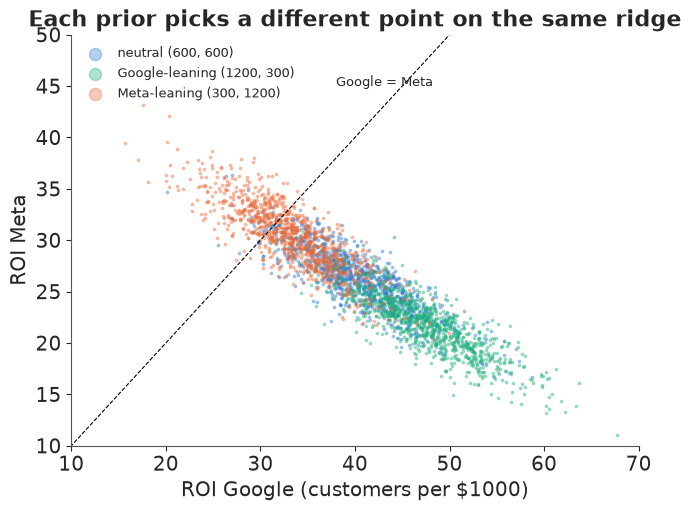

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for (name, idt), col in zip(fits_a.items(), [BLUE, AQUA, ORANGE]):
    r = az.extract(idt, var_names=["roi"]).values
    ax.scatter(r[0, ::4], r[1, ::4], s=3, alpha=0.35, color=col, label=name)
ax.plot([0, 70], [0, 70], color="k", lw=0.8, ls="--")
ax.text(38, 45, "Google = Meta", fontsize=9)
ax.set(xlim=(10, 70), ylim=(10, 50), xlabel="ROI Google (customers per $1000)", ylabel="ROI Meta",
       title="Each prior picks a different point on the same ridge")
ax.legend(markerscale=5, fontsize=9);

## A5 · A second, deeper ridge: baseline vs media

So answer the total instead? Not yet. Customers grew tenfold, and so did spend. The linear-trend
baseline says growth that spend does not explain must be a straight line on the log scale; a
more flexible baseline (a random walk moving every 4 weeks) can follow the slow growth itself
and leave less for media. Both are ordinary modelling choices.

In [11]:
with build_mmm(baseline="rw") as mmm_rw:
    idata_rw = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.9)
print("divergences:", int(idata_rw.sample_stats["diverging"].sum()))
az.summary(idata_rw, var_names=["roi", "roi_total", "mroi", "s_rw", "alpha"], round_to=3)

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
roi[google],26.230,4.449,19.069,33.293,3947.737,3501.016,1.000,0.071,0.060
roi[meta],23.915,2.358,20.227,27.663,3479.699,3542.842,1.000,0.040,0.029
roi_total,24.765,1.415,22.461,27.005,3362.323,3183.590,1.000,0.024,0.019
mroi,18.306,1.571,15.721,20.790,2668.521,3047.135,1.000,0.030,0.022
s_rw,0.288,0.049,0.214,0.371,2481.888,2392.703,1.001,0.001,0.001
alpha,62.242,9.547,48.053,78.400,2905.612,2949.009,1.000,0.176,0.138


In [12]:
base_share = {k: float(az.extract(i, var_names=["base"]).values.mean(axis=1).sum() / y.sum())
              for k, i in [("linear", idata_a), ("random walk", idata_rw)]}
print("share of new customers the baseline explains:", {k: round(v, 2) for k, v in base_share.items()})
print("ROI total, linear baseline      :", q(tot_a))
print("ROI total, random-walk baseline :", q(az.extract(idata_rw, var_names=["roi_total"]).values))

share of new customers the baseline explains: {'linear': 0.12, 'random walk': 0.32}
ROI total, linear baseline      : [29.55 31.41 33.05]
ROI total, random-walk baseline : [22.39 24.79 27.08]


Both fits are clean and precise, and their total ROIs do not overlap. The baseline's share of
customers roughly triples. Which baseline is right? The usual tool is predictive accuracy:

In [13]:
loo_a = {}
for name, m, idt in [("linear baseline", mmm, idata_a), ("random-walk baseline", mmm_rw, idata_rw)]:
    ll = idt.copy()
    with m:
        pm.compute_log_likelihood(ll, progressbar=False)
    loo_a[name] = az.loo(ll)
az.compare(loo_a, round_to=1)

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
random-walk baseline,0,0.0,0.0,NaN,,1 k̂ > 0.70,23.9,-877.8,11.1,1.0
linear baseline,1,-43.6,6.3,1.0,,1 k̂ > 0.70,11.7,-921.4,11.0,0.0


LOO strongly prefers the random walk: it predicts held-out weeks better (a few weeks have
Pareto $\hat k > 0.7$ in both models, so the difference is approximate, but it is many standard
errors wide). That is **not**
evidence about attribution. A flexible baseline predicts better because it can follow any slow
movement in $y$, whether its cause is the brand's growth or slow-acting media. Predictive
accuracy ranks models of $y$; "how much of $y$ did media cause" is a causal question about
which weeks with *different* spend would have looked like, and in this data spend and the slow
trend moved together. Neither the prior nor LOO can settle it. (The Google-Meta difference also
shrinks to almost nothing under the random walk, another sign it was never data-driven.)

## A6 · Fake data: is it the model or the data?

A fair objection: maybe the model is simply wrong, and a better model would identify the split.
The fake-data check answers this. Simulate new customers from **this model** with known
parameters, on the brand's real spend, and refit. We choose a truth where **Meta is twice as
efficient as Google**, the reverse of what the default fit claimed. If even the correct model
cannot recover the truth, no amount of model improvement will: the spend history does not
contain the information.

We then add what would contain it: **one experiment**. A geo holdout test (switch Google off in
a random half of regions for a few weeks) measures Google's ROI directly, with a standard error
of 10% here.

In [14]:
truth = dict(theta=np.array([0.30, 0.15]), lam=np.array([0.35, 0.35]),
             beta=np.array([600.0, 2000.0]), b0=3.98, b1=0.17, alpha=30.0)
w_true = (1 - truth["theta"])[:, None] * truth["theta"][:, None] ** np.arange(L_ADSTOCK)
a_true = (lags * (w_true / w_true.sum(axis=1, keepdims=True))[None]).sum(axis=-1)
contrib_true = truth["beta"] * (1 - np.exp(-truth["lam"] * a_true))
roi_true = 1000 * contrib_true.sum(axis=0) / X.sum(axis=0)
mu_true = np.exp(truth["b0"] + truth["b1"] * tt) + contrib_true.sum(axis=1)
rng_fake = np.random.default_rng(3)
y_fake = rng_fake.negative_binomial(truth["alpha"], truth["alpha"] / (truth["alpha"] + mu_true))
lift_obs = roi_true[0] * (1 + 0.10 * rng_fake.normal())
print("true ROI (Google, Meta):", roi_true.round(1), f"| experiment reports Google ROI {lift_obs:.1f} "
      f"+- {0.10 * roi_true[0]:.1f}")

rows, fake_draws = [], {}
for with_lift in (False, True):
    for name, sd in PRIORS.items():
        lift = (0, lift_obs, 0.10 * roi_true[0]) if with_lift else None
        with build_mmm(beta_sd=sd, y_obs=y_fake, lift=lift):
            idf = pm.sample(random_seed=RANDOM_SEED, progressbar=False, var_names=["roi"])
        r = az.extract(idf, var_names=["roi"]).values
        fake_draws[(with_lift, name)] = r
        rows.append({"experiment": "yes" if with_lift else "no", "prior on beta": name,
                     "ROI Google": f"{np.median(r[0]):.1f}", "ROI Meta": f"{np.median(r[1]):.1f}",
                     "P(Google > Meta)": round(float((r[0] > r[1]).mean()), 3),
                     "divergences": int(idf.sample_stats["diverging"].sum())})
fake_tab = pd.DataFrame(rows).set_index(["experiment", "prior on beta"])
fake_tab

true ROI (Google, Meta): [19.6 38.2] | experiment reports Google ROI 18.0 +- 2.0


ROI Google ROI Meta  P(Google > Meta)  \
experiment prior on beta                                                      
no         neutral (600, 600)               24.5     35.2             0.052   
           Google-leaning (1200, 300)       29.2     31.7             0.354   
           Meta-leaning (300, 1200)         21.8     37.2             0.009   
yes        neutral (600, 600)               19.2     37.9             0.000   
           Google-leaning (1200, 300)       20.0     36.1             0.000   
           Meta-leaning (300, 1200)         18.7     38.9             0.000   

                                       divergences  
experiment prior on beta                            
no         neutral (600, 600)                    0  
           Google-leaning (1200, 300)            0  
           Meta-leaning (300, 1200)              0  
yes        neutral (600, 600)                    0  
           Google-leaning (1200, 300)            0  
           Meta-leaning (300, 1200)              0

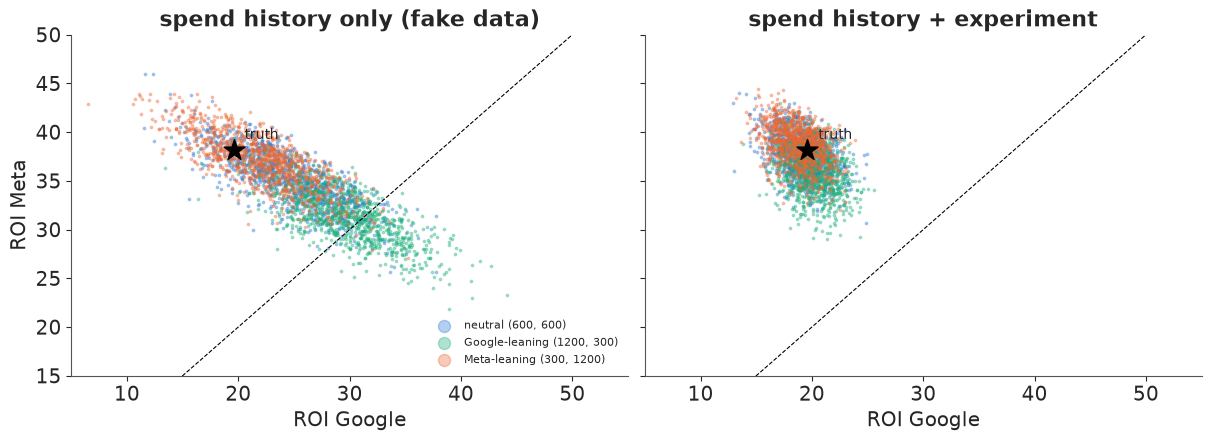

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharex=True, sharey=True)
for ax, with_lift in zip(axes, (False, True)):
    for (name, _), col in zip(PRIORS.items(), [BLUE, AQUA, ORANGE]):
        r = fake_draws[(with_lift, name)]
        ax.scatter(r[0, ::4], r[1, ::4], s=3, alpha=0.35, color=col, label=name)
    ax.scatter(*roi_true, marker="*", s=250, color="k", zorder=5)
    ax.annotate("truth", roi_true, xytext=(8, 8), textcoords="offset points", fontsize=10)
    ax.plot([0, 70], [0, 70], color="k", lw=0.8, ls="--")
    ax.set(xlim=(5, 55), ylim=(15, 50), xlabel="ROI Google",
           title="spend history + experiment" if with_lift else "spend history only (fake data)")
axes[0].set_ylabel("ROI Meta")
axes[0].legend(markerscale=5, fontsize=8);

Without the experiment, even the true model on data it generated itself gives an answer that
depends on the prior, and the Google-leaning prior is far from the truth. The spend history
is the problem, not the model. With one experiment on one channel, the three priors agree and
land on the truth: the experiment fixes Google's ROI, and the ridge (which pins the total)
then fixes Meta's. This is the constructive pivot for the original question: **the answer
needs a different kind of data, and we can say which.**

## A7 · Pivot: answer the decision, and say what the data cannot

Until an experiment runs, what can we honestly tell the marketing lead? Their real decision
included "should the budget go up at all?" That needs the **marginal** cost of a customer when
total spend rises in the current mix, $1000 / \text{mROI}$, compared with what a new customer is
worth to the brand (their margin, which they know and we do not). The marginal ROI depends on
the baseline too, so the honest answer is **a decision that holds across every model we find
plausible**, and an explicit region where it does not.

          neutral (600, 600): marginal cost per new customer ($) [38.45 41.89 46.66]
  Google-leaning (1200, 300): marginal cost per new customer ($) [38.53 42.21 47.12]
    Meta-leaning (300, 1200): marginal cost per new customer ($) [37.64 41.35 46.33]
        random-walk baseline: marginal cost per new customer ($) [47.93 54.55 63.98]
all four models agree (P < 0.1 or P > 0.9) outside $38 - $62


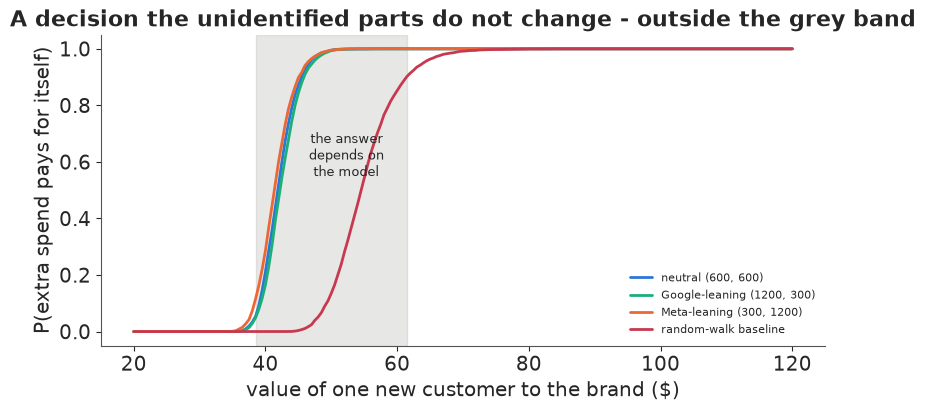

In [16]:
values = np.linspace(20, 120, 201)  # what one new customer is worth to the brand, $
curves = {}
for name, idt in list(fits_a.items()) + [("random-walk baseline", idata_rw)]:
    mcac = 1000 / az.extract(idt, var_names=["mroi"]).values
    curves[name] = [(mcac < v).mean() for v in values]
    print(f"{name:>28}: marginal cost per new customer ($) {q(mcac)}")

fig, ax = plt.subplots(figsize=(8, 4))
for (name, cur), col in zip(curves.items(), [BLUE, AQUA, ORANGE, RED]):
    ax.plot(values, cur, color=col, lw=2, label=name)
v_yes = values[np.argmax(np.min(list(curves.values()), axis=0) > 0.9)]  # all models: P > 0.9
v_no = values[np.argmax(np.max(list(curves.values()), axis=0) > 0.1)]  # below: all P < 0.1
ax.axvspan(v_no, v_yes, color=GREY, alpha=0.2)
ax.text(v_no + 0.6 * (v_yes - v_no), 0.55, "the answer\ndepends on\nthe model", ha="center", fontsize=9)
ax.set(xlabel="value of one new customer to the brand ($)",
       ylabel="P(extra spend pays for itself)",
       title="A decision the unidentified parts do not change - outside the grey band")
ax.legend(fontsize=8, loc="lower right");
print(f"all four models agree (P < 0.1 or P > 0.9) outside ${v_no:.0f} - ${v_yes:.0f}")

If a new customer is worth more than the upper edge of the band, every model says spend more;
below the lower edge, every model says spend less. Inside the band the answer depends on an
assumption the data cannot check, and that is what we report, together with the experiment
that would settle it.

In [17]:
audit = []
audit.append(dict(part="A", asked="Is Google or Meta more efficient?",
                  answered="not answerable from this spend history: it follows the prior "
                           f"(P(Google better) {sens_a['P(Google > Meta)'].min():.2f}-"
                           f"{sens_a['P(Google > Meta)'].max():.2f} across three priors)",
                  why="spend on the two channels moved together; the data fix a weighted sum",
                  next_step="geo holdout on one channel (fake-data check: a 10%-SE test on Google "
                            "makes all priors agree)"))
audit.append(dict(part="A", asked="(fallback) total return of paid media",
                  answered="depends on the baseline assumption (median "
                           f"{np.median(az.extract(idata_rw, var_names=['roi_total']).values):.0f} "
                           f"vs {np.median(tot_a):.0f} customers per $1000)",
                  why="slow growth and spend moved together; LOO ranks fit, not attribution",
                  next_step="report both; the same experiment calibrates the total"))
audit.append(dict(part="A", asked="Should the total budget go up?",
                  answered=f"yes if a customer is worth > ${v_yes:.0f}, no if < ${v_no:.0f}, "
                           "undetermined between",
                  why="the decision threshold falls outside the band for most values",
                  next_step="the brand supplies the value of a customer"))

---
# Part B · Too expensive to compute: a smooth demand trend

## B1 · The question

In [18]:
QB = Question(
    asked="How much did underlying bike-share demand grow from 2011 to 2012, beyond weather "
          "and the day of the week? We are sizing next year's fleet.",
    quantity="ratio of the smooth demand level, 2012 average / 2011 average",
    population="Capital Bikeshare, Washington DC, all stations",
    scale="multiplicative growth (1.5 = 50% more rides)",
    decision="fleet size for 2013",
)
QB.show()
data.describe("bike_hour")
bikes = data.load("bike_hour")
bikes["dteday"] = pd.to_datetime(bikes["dteday"])
print(f"{len(bikes):,} hourly rows, {bikes.dteday.min().date()} -> {bikes.dteday.max().date()}")

     asked: How much did underlying bike-share demand grow from 2011 to 2012, beyond weather and the day of the week? We are sizing next year's fleet.
  quantity: ratio of the smooth demand level, 2012 average / 2011 average
population: Capital Bikeshare, Washington DC, all stations
     scale: multiplicative growth (1.5 = 50% more rides)
  decision: fleet size for 2013
bike_hour: Hourly rental counts 2011-2012 with weather and calendar covariates.
  source: Fanaee-T & Gama (2013), Capital Bikeshare (Washington DC), UCI ML Repository.
  url:    https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip
17,379 hourly rows, 2011-01-01 -> 2012-12-31


The natural model is a Gaussian process over time: a smooth latent level with unknown
smoothness, plus hour-of-day and weather effects, on all 17,379 hours. A GP with $n$ points
needs an $n \times n$ covariance matrix and its Cholesky factor at every gradient evaluation:
$O(n^2)$ memory and $O(n^3)$ time.

## B2 · Price the model before running it

Never launch a sampler on a model you have not timed. Time **one gradient** of the log density
on growing random subsets, fit the growth rate, extrapolate. A NUTS fit needs roughly
chains x (warm-up + draws) x leapfrog steps gradients; 4 x 1400 x 15 is a modest guess.

   n  ms per gradient
 200              0.4
 400              2.1
 800             12.4
1600             86.1
growth exponent 2.69 (theory: 3)
n = 17,379: ~52 s per gradient -> 50 days for one fit; one 17,379^2 matrix = 2.4 GB


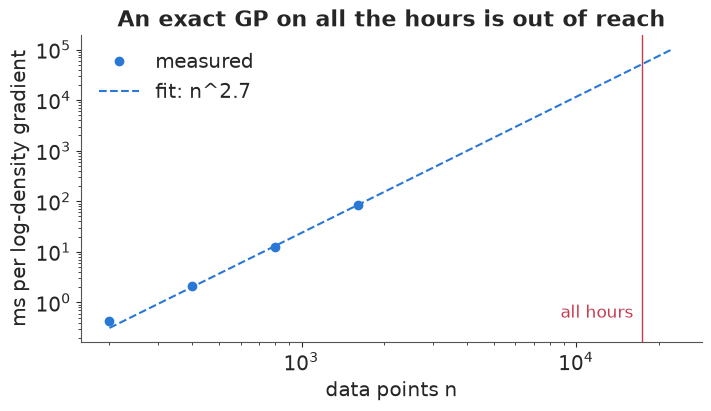

In [19]:
t_hours = ((bikes.dteday - bikes.dteday.min()).dt.days + bikes.hr / 24).to_numpy()
log_cnt = np.log(bikes.cnt.to_numpy())


def exact_gp_logp_grad_time(n, seconds=1.0):
    idx = np.sort(np.random.default_rng(n).choice(len(t_hours), n, replace=False))
    with pm.Model() as m:
        ell = pm.InverseGamma("ell", 5, 200)
        eta = pm.HalfNormal("eta", 1)
        sigma = pm.HalfNormal("sigma", 1)
        gp = pm.gp.Marginal(cov_func=eta**2 * pm.gp.cov.ExpQuad(1, ls=ell))
        gp.marginal_likelihood("y", X=t_hours[idx, None], y=log_cnt[idx] - log_cnt.mean(),
                               sigma=sigma)
    dlogp, point = m.compile_dlogp(), m.initial_point()
    dlogp(point)
    t0, k = time.perf_counter(), 0
    while time.perf_counter() - t0 < seconds:
        dlogp(point)
        k += 1
    return (time.perf_counter() - t0) / k


sizes = np.array([200, 400, 800, 1600])
grad_s = np.array([exact_gp_logp_grad_time(n) for n in sizes])
slope, intercept = np.polyfit(np.log(sizes[1:]), np.log(grad_s[1:]), 1)
N_ALL = len(bikes)
pred_grad = np.exp(intercept) * N_ALL**slope
n_grads = 4 * 1400 * 15
print(pd.DataFrame({"n": sizes, "ms per gradient": (grad_s * 1e3).round(1)}).to_string(index=False))
print(f"growth exponent {slope:.2f} (theory: 3)")
print(f"n = {N_ALL:,}: ~{pred_grad:.0f} s per gradient -> {pred_grad * n_grads / 86400:.0f} days "
      f"for one fit; one {N_ALL:,}^2 matrix = {N_ALL**2 * 8 / 1e9:.1f} GB")

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(sizes, grad_s * 1e3, "o", color=BLUE, label="measured")
nn = np.logspace(np.log10(200), np.log10(N_ALL * 1.3), 50)
ax.loglog(nn, np.exp(intercept) * nn**slope * 1e3, color=BLUE, ls="--", label=f"fit: n^{slope:.1f}")
ax.axvline(N_ALL, color=RED, lw=1)
ax.text(N_ALL * 0.93, 0.5, "all hours", color=RED, ha="right")
ax.set(xlabel="data points n", ylabel="ms per log-density gradient",
       title="An exact GP on all the hours is out of reach");
ax.legend();

Months of computing, and 2.4 GB for each $n \times n$ matrix (a gradient keeps several alive) on
an 8 GB laptop: no. The failure is predictable in about ten seconds, which is the point of timing
first. There are three kinds of pivot, in order of preference:

1. **Shrink the data to the resolution the question needs.** The question is about a smooth
   level over two years. Hours carry the within-day pattern, which is a nuisance here. Daily
   totals (731 rows) or weekly totals (104) keep what the question needs.
2. **Approximate the model.** A Hilbert-space GP (HSGP, E05) replaces the $n \times n$ matrix by
   $m$ basis functions: cost $O(nm)$.
3. **Shrink the question.** If neither works, answer something coarser (a yearly comparison of
   means) and say so.

A pivot changes what can be answered. Daily totals cannot say anything about rush hours; that
is fine only because the contract did not ask.

## B3 · Pivot 1 + 2: daily totals with an HSGP

Daily rentals, a negative binomial likelihood, a smooth HSGP level (Matérn 5/2, 60 basis
functions), a working-day effect and the day's worst weather. One gradient, then the fit:

In [20]:
day = (bikes.groupby("dteday")
       .agg(cnt=("cnt", "sum"), workingday=("workingday", "first"), weather=("weathersit", "max"))
       .reset_index())
day["t"] = (day.dteday - day.dteday.min()).dt.days
t_center = day.t.mean()
tc_day = (day.t.to_numpy() - t_center) / 365  # years, centred
year_day = day.dteday.dt.year.to_numpy()
weather_idx = day.weather.clip(upper=3).to_numpy() - 1  # 3 = rain/snow (one day with 4 folded in)

with pm.Model(coords={"weather": ["clear", "mist", "rain/snow"], "day": day.dteday}) as daily_gp:
    ell = pm.InverseGamma("ell", 5, 0.5)  # years; prior mode ~ 1 month
    eta = pm.HalfNormal("eta", 1.0)
    gp = pm.gp.HSGP(m=[60], c=1.5, cov_func=eta**2 * pm.gp.cov.Matern52(1, ls=ell))
    f = gp.prior("f", X=tc_day[:, None], dims="day")
    c0 = pm.Normal("c0", np.log(day.cnt.mean()), 1)
    b_work = pm.Normal("b_work", 0, 0.5)
    b_weather = pm.ZeroSumNormal("b_weather", 0.5, dims="weather")
    level = pm.Deterministic("level", pt.exp(c0 + f), dims="day")
    mu = level * pt.exp(b_work * day.workingday.to_numpy() + b_weather[weather_idx])
    alpha_d = pm.Gamma("alpha", 2, 0.1)
    pm.NegativeBinomial("rentals", mu=mu, alpha=alpha_d, observed=day.cnt.to_numpy(), dims="day")

dlogp, point = daily_gp.compile_dlogp(), daily_gp.initial_point()
dlogp(point)
t0 = time.perf_counter()
for _ in range(200):
    dlogp(point)
print(f"daily HSGP: {(time.perf_counter() - t0) / 200 * 1e3:.2f} ms per gradient")
t0 = time.perf_counter()
with daily_gp:
    idata_day = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.95,
                          var_names=["ell", "eta", "c0", "b_work", "b_weather", "alpha", "level"])
print(f"fit {time.perf_counter() - t0:.0f} s, divergences "
      f"{int(idata_day.sample_stats['diverging'].sum())}, max tree depth "
      f"{int(idata_day.sample_stats['depth'].max())}")
az.summary(idata_day, var_names=["ell", "eta", "b_work", "b_weather", "alpha"], round_to=3)

daily HSGP: 0.08 ms per gradient


fit 16 s, divergences 1, max tree depth 8


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
ell,0.173,0.058,0.110,0.280,369.005,443.034,1.011,0.003,0.004
eta,0.630,0.194,0.408,0.972,439.100,620.996,1.003,0.010,0.012
b_work,0.074,0.021,0.040,0.107,5752.103,2652.954,1.001,0.000,0.000
b_weather[clear],0.050,0.016,0.024,0.076,6398.955,3031.674,1.003,0.000,0.000
b_weather[mist],0.082,0.013,0.062,0.104,6024.901,3342.823,1.002,0.000,0.000
b_weather[rain/snow],-0.133,0.014,-0.155,-0.110,6291.558,3166.640,1.002,0.000,0.000
alpha,14.766,0.847,13.438,16.173,2988.075,2613.274,1.001,0.015,0.014


A fraction of a millisecond per gradient, and a fit in seconds (a divergence or two at
`target_accept=0.95` in the HSGP fits here; the growth answers below agree with the exact
model, which has none). (While writing this notebook we also fitted the same
HSGP on all 17,379 *hours* with hour-of-day effects: about 1 ms per gradient, but the fit took
about 8 minutes because the sampler needed long trajectories. Feasible, and no better for this
question.)

## B4 · Check the approximation where the exact model is still feasible

An approximation needs a check against the exact answer. We cannot run the exact model on the
full data, but we can on **weekly** totals (104 points, a few ms per gradient). Fit the same GP
on weekly log totals twice, exactly and with an HSGP; if the two agree there, the HSGP settings
are adequate for a trend this smooth.

In [21]:
weekly = day.set_index("dteday")["cnt"].resample("W-SUN").agg(["sum", "count"])
weekly = weekly[weekly["count"] == 7]
tc_wk = ((weekly.index - day.dteday.min()).days.to_numpy() - 3 - t_center) / 365  # mid-week
log_wk = np.log(weekly["sum"].to_numpy())
year_wk = weekly.index.year.to_numpy()


def weekly_gp(exact):
    with pm.Model() as m:
        ell = pm.InverseGamma("ell", 5, 0.5)
        eta = pm.HalfNormal("eta", 1.0)
        sigma = pm.HalfNormal("sigma", 0.3)
        c0 = pm.Normal("c0", log_wk.mean(), 1)
        cov = eta**2 * pm.gp.cov.Matern52(1, ls=ell)
        if exact:
            gp = pm.gp.Marginal(mean_func=pm.gp.mean.Constant(c0), cov_func=cov)
            gp.marginal_likelihood("y", X=tc_wk[:, None], y=log_wk, sigma=sigma)
            idt = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
            gp.conditional("f_week", Xnew=tc_wk[:, None], pred_noise=False)
            pp = pm.sample_posterior_predictive(idt, var_names=["f_week"], random_seed=RANDOM_SEED,
                                                progressbar=False)
            f_draws = az.extract(pp, group="posterior_predictive", var_names=["f_week"]).values
        else:
            hs = pm.gp.HSGP(m=[30], c=1.5, cov_func=cov)
            pm.Deterministic("f_week", c0 + hs.prior("f", X=tc_wk[:, None]))
            pm.Normal("y", m["f_week"], sigma, observed=log_wk)
            idt = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.95)
            f_draws = az.extract(idt, var_names=["f_week"]).values
    return idt, f_draws


t0 = time.perf_counter()
idata_wk_exact, fw_exact = weekly_gp(exact=True)
idata_wk_hsgp, fw_hsgp = weekly_gp(exact=False)
print(f"both weekly fits: {time.perf_counter() - t0:.0f} s; divergences exact / HSGP: "
      f"{int(idata_wk_exact.sample_stats['diverging'].sum())} / "
      f"{int(idata_wk_hsgp.sample_stats['diverging'].sum())}")
print("max |difference| of the posterior median log-trend, exact vs HSGP:",
      round(float(np.abs(np.median(fw_exact, 1) - np.median(fw_hsgp, 1)).max()), 3))

both weekly fits: 5 s; divergences exact / HSGP: 0 / 2
max |difference| of the posterior median log-trend, exact vs HSGP: 0.021


In [22]:
def growth(level_draws, years):
    return level_draws[years == 2012].mean(axis=0) / level_draws[years == 2011].mean(axis=0)


lvl_day = az.extract(idata_day, var_names=["level"]).values
growth_tab = pd.DataFrame({
    "weekly totals, exact GP": q(growth(np.exp(fw_exact), year_wk)),
    "weekly totals, HSGP": q(growth(np.exp(fw_hsgp), year_wk)),
    "daily totals, HSGP (+ weather, working day)": q(growth(lvl_day, year_day)),
}, index=["5%", "50%", "95%"]).T
growth_tab

,5%,50%,95%
"weekly totals, exact GP",1.54,1.61,1.69
"weekly totals, HSGP",1.54,1.61,1.69
"daily totals, HSGP (+ weather, working day)",1.58,1.64,1.69


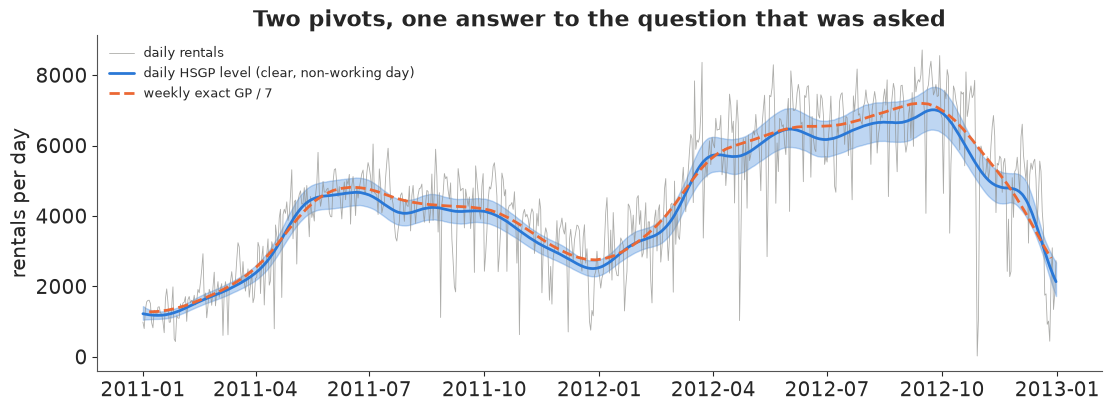

In [23]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(day.dteday, day.cnt, color=GREY, lw=0.6, alpha=0.7, label="daily rentals")
lv = np.quantile(lvl_day, [0.05, 0.5, 0.95], axis=1)
ax.fill_between(day.dteday, lv[0], lv[2], color=BLUE, alpha=0.3)
ax.plot(day.dteday, lv[1], color=BLUE, lw=2, label="daily HSGP level (clear, non-working day)")
fe = np.quantile(np.exp(fw_exact) / 7, [0.05, 0.5, 0.95], axis=1)
ax.plot(weekly.index - pd.Timedelta(days=3), fe[1], color=ORANGE, lw=2, ls="--",
        label="weekly exact GP / 7")
ax.set(ylabel="rentals per day", title="Two pivots, one answer to the question that was asked")
ax.legend(fontsize=9);

The three routes agree on growth of roughly 60% (the table above), and the HSGP matches the
exact GP where both can run. The two curves are on slightly different scales (the daily level
is for a clear, non-working day; the weekly one averages over all days), which the growth
*ratio* removes. That is one reason to define the question as a ratio in the contract.

In [24]:
audit.append(dict(part="B", asked="Growth in underlying demand, 2011 -> 2012",
                  answered=f"about {growth_tab.iloc[2, 1]:.2f}x (90%: {growth_tab.iloc[2, 0]:.2f}-"
                           f"{growth_tab.iloc[2, 2]:.2f}); weekly exact GP agrees",
                  why="exact GP on 17k hours: weeks of computing, GBs per matrix",
                  next_step="gave up hour-level structure (not asked); HSGP checked against exact"))

---
# Part C · Keeping the answer on the question: an HIV treatment trial

## C1 · Three questions from a clinic

ACTG 175 randomised HIV-infected adults to zidovudine (ZDV) alone, ZDV + didanosine (ddI),
ZDV + zalcitabine, or ddI alone, and followed them for a clinical event (AIDS, death, or a 50%
drop in CD4 cells). (C11 uses the same trial's CD4 counts for treatment-effect heterogeneity.)
A clinic asks three questions:

In [25]:
QC1 = Question(
    asked="Our patients are mostly symptomatic and have had antiretrovirals before. Out of 100 "
          "such patients, how many fewer will have an event within 2 years on ZDV + ddI than on ZDV?",
    quantity="2-year risk difference, ZDV minus ZDV+ddI",
    population="symptomatic, ART-experienced patients (the clinic's case mix)",
    scale="events per 100 patients over 730 days",
    decision="whether switching these patients justifies the extra toxicity of ddI",
)
QC2 = Question(
    asked="Which of the three newer regimens is best?",
    quantity="P(each regimen has the lowest hazard)",
    population="trial population", scale="probability", decision="formulary choice")
QC3 = Question(
    asked="Which kind of patient benefits most from adding ddI?",
    quantity="subgroup-specific effects of ddI, and their ranking",
    population="8 subgroups: symptoms x prior ART x CD4 above/below 340",
    scale="relative (hazard ratio) - or absolute?", decision="whom to prioritise")
QC1.show()

     asked: Our patients are mostly symptomatic and have had antiretrovirals before. Out of 100 such patients, how many fewer will have an event within 2 years on ZDV + ddI than on ZDV?
  quantity: 2-year risk difference, ZDV minus ZDV+ddI
population: symptomatic, ART-experienced patients (the clinic's case mix)
     scale: events per 100 patients over 730 days
  decision: whether switching these patients justifies the extra toxicity of ddI


## C2 · A piecewise-exponential survival model

Hazard constant within five follow-up windows (0-180-365-540-730-1300 days), proportional
effects of arm and baseline covariates (age, log CD4, symptoms, prior ART, Karnofsky score).
Written as a Poisson model on person-window rows with log exposure as an offset, it samples in
seconds.

In [26]:
data.describe("actg175")
actg = data.load("actg175").reset_index()
cuts = np.array([0, 180, 365, 540, 730, 1300.0])
K = len(cuts) - 1
covs = pd.DataFrame({
    "age": (actg.age - 35) / 10,
    "log_cd4": (np.log(actg.cd40.clip(lower=10)) - np.log(350)) / 0.35,
    "symptomatic": actg.symptom,
    "prior_art": actg.str2,
    "karnofsky": (actg.karnof - 95) / 6,
})
Xc = covs.to_numpy(float)
arm = actg.trt.to_numpy()
ARMS = ["ZDV", "ZDV+ddI", "ZDV+zal", "ddI"]
pieces = []
for k in range(K):
    at_risk = actg.time.to_numpy() > cuts[k]
    exposure = np.clip(actg.time.to_numpy(), cuts[k], cuts[k + 1]) - cuts[k]
    event = (actg.cid.to_numpy() == 1) & at_risk & (actg.time.to_numpy() <= cuts[k + 1])
    pieces.append(pd.DataFrame({"i": np.where(at_risk)[0], "k": k, "exposure": exposure[at_risk],
                                "event": event[at_risk].astype(int)}))
pw = pd.concat(pieces, ignore_index=True)
print(f"{len(actg)} patients, {len(pw)} person-window rows, {pw.event.sum()} events")

with pm.Model(coords={"window": np.arange(K), "new_arm": ARMS[1:], "cov": list(covs)}) as surv:
    log_base = pm.Normal("log_base", np.log(0.3 / 365), 1.5, dims="window")
    b_new = pm.Normal("b_arm", 0, 1, dims="new_arm")  # log hazard ratio vs ZDV alone
    b_arm = pt.concatenate([pt.zeros(1), b_new])
    b_x = pm.Normal("b_x", 0, 1, dims="cov")
    ii = pw.i.to_numpy()
    eta_c = log_base[pw.k.to_numpy()] + b_arm[arm[ii]] + Xc[ii] @ b_x + np.log(pw.exposure.to_numpy())
    pm.Poisson("event", pt.exp(eta_c), observed=pw.event.to_numpy())
    idata_c = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print("divergences:", int(idata_c.sample_stats["diverging"].sum()))
az.summary(idata_c, var_names=["b_arm", "b_x"], round_to=3)

actg175: 2139 HIV-infected adults with 200-500 CD4 cells/mm3, randomised to zidovudine (ZDV, trt 0), ZDV + didanosine (trt 1), ZDV + zalcitabine (trt 2) or didanosine alone (trt 3). One row per patient: baseline covariates (age, wtkg, hemo, homo, drugs, karnof, race, gender, str2 = prior antiretroviral therapy, symptom, ...), CD4/CD8 counts at baseline (cd40, cd80) and at 20 +- 5 weeks (cd420, cd820), and time to a clinical event (time, cid).
  source: Hammer et al. (1996, New England Journal of Medicine 335:1081), AIDS Clinical Trials Group Study 175; UCI Machine Learning Repository dataset 890 (doi:10.24432/C5ZG8F), the same data as the R package `speff2trial` (Juraska et al.).
  url:    https://archive.ics.uci.edu/static/public/890/data.csv
2139 patients, 9524 person-window rows, 521 events


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b_arm[ZDV+ddI],-0.822,0.126,-1.026,-0.618,3295.135,3329.287,1.001,0.002,0.002
b_arm[ZDV+zal],-0.658,0.120,-0.854,-0.463,3290.205,3046.954,1.001,0.002,0.002
b_arm[ddI],-0.543,0.114,-0.726,-0.363,2438.182,2857.277,1.000,0.002,0.001
b_x[age],0.065,0.050,-0.016,0.145,8234.276,3243.620,1.000,0.001,0.001
b_x[log_cd4],-0.266,0.028,-0.310,-0.220,6909.068,3354.758,1.000,0.000,0.000
b_x[symptomatic],0.494,0.099,0.335,0.650,6122.611,3371.674,1.001,0.001,0.002
b_x[prior_art],0.357,0.095,0.205,0.507,2413.317,2529.404,1.001,0.002,0.001
b_x[karnofsky],-0.153,0.041,-0.217,-0.084,7491.358,3301.023,1.001,0.000,0.001


## C3 · Three true numbers, one answer

The model's natural output is the log hazard ratio. Reported as "HR 0.44" it is correct, and
it does not answer the clinic, which asked for **events per 100 of its own patients over two
years**. That needs each patient's 2-year risk under both arms, computed from the posterior,
averaged over the population the question names (g-computation / standardisation).

In [27]:
b_draws = az.extract(idata_c, var_names=["b_arm"]).values  # (3, S)
b_draws = np.vstack([np.zeros(b_draws.shape[1]), b_draws])  # ZDV = reference
lb_draws = az.extract(idata_c, var_names=["log_base"]).values
bx_draws = az.extract(idata_c, var_names=["b_x"]).values
days_in_window = np.clip(730 - cuts[:-1], 0, np.diff(cuts))  # exposure to day 730 per window
H0_730 = (np.exp(lb_draws) * days_in_window[:, None]).sum(axis=0)  # baseline cumulative hazard
lin_pred = Xc @ bx_draws  # (patients, S)


def risk_730(j, rows):
    """2-year event risk under arm j for the selected patients: (patients, S)."""
    return 1 - np.exp(-H0_730[None] * np.exp(lin_pred[rows] + b_draws[j][None]))


clinic = ((actg.symptom == 1) & (actg.str2 == 1)).to_numpy()
low_risk = ((actg.symptom == 0) & (actg.str2 == 0) & (actg.cd40 > 350)).to_numpy()
everyone = np.ones(len(actg), bool)
hr = np.exp(b_draws[1])
answers = {
    "hazard ratio ZDV+ddI vs ZDV": q(hr),
    "  ...misread as 'fewer events per 100'": q(100 * (1 - hr)),
    "risk difference per 100, trial population": q(100 * (risk_730(0, everyone) - risk_730(1, everyone)).mean(0)),
    f"risk difference per 100, clinic case mix (n={clinic.sum()})":
        q(100 * (risk_730(0, clinic) - risk_730(1, clinic)).mean(0)),
    f"risk difference per 100, low-risk patients (n={low_risk.sum()})":
        q(100 * (risk_730(0, low_risk) - risk_730(1, low_risk)).mean(0)),
}
ans_tab = pd.DataFrame(answers, index=["5%", "50%", "95%"]).T
ans_tab

,5%,50%,95%
hazard ratio ZDV+ddI vs ZDV,0.36,0.44,0.54
...misread as 'fewer events per 100',45.78,55.99,64.37
"risk difference per 100, trial population",10.00,13.26,16.56
"risk difference per 100, clinic case mix (n=229)",15.73,21.12,26.55
"risk difference per 100, low-risk patients (n=416)",6.00,8.02,10.24


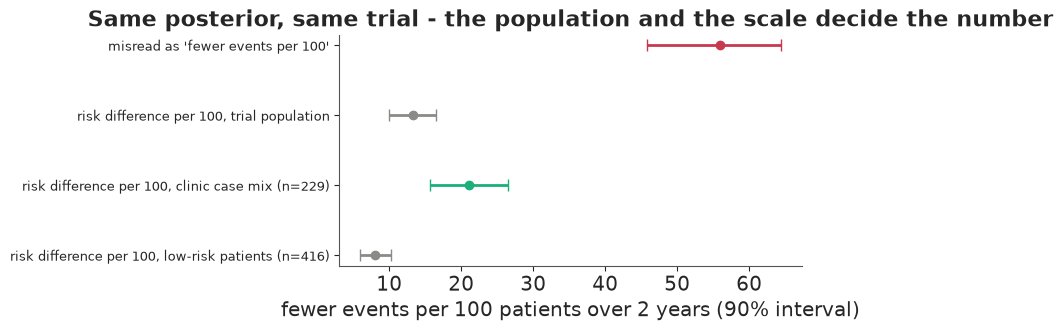

In [28]:
fig, ax = plt.subplots(figsize=(8, 3.2))
labels_c = list(answers)[1:]
for i, lab in enumerate(labels_c):
    lo_, mid, hi_ = answers[lab]
    col = AQUA if "clinic" in lab else (RED if "misread" in lab else GREY)
    ax.errorbar(mid, i, xerr=[[mid - lo_], [hi_ - mid]], fmt="o", color=col, capsize=4, lw=2)
ax.set_yticks(range(len(labels_c)), [s.strip(" .") for s in labels_c], fontsize=9)
ax.invert_yaxis()
ax.set(xlabel="fewer events per 100 patients over 2 years (90% interval)",
       title="Same posterior, same trial - the population and the scale decide the number");

All from one posterior. The hazard ratio read as a percentage says 56 fewer events per 100;
the real absolute benefit is about 13 per 100 on average in the trial, about 21 in the
clinic's higher-risk case mix, and about 8 in low-risk patients. A common HR means a larger
absolute benefit where baseline risk is higher. Only one row answers QC1.

## C4 · "Which regimen is best?" - and the question just below it

In [29]:
p_best = np.bincount(np.argmin(b_draws[1:], axis=0), minlength=3) / b_draws.shape[1]
p_better = (b_draws[1:] < 0).mean(axis=1)
print(pd.DataFrame({"P(best of the three)": p_best.round(3), "P(better than ZDV alone)": p_better.round(3),
                    "HR vs ZDV (median)": np.exp(np.median(b_draws[1:], axis=1)).round(2)},
                   index=ARMS[1:]).to_string())

         P(best of the three)  P(better than ZDV alone)  HR vs ZDV (median)
ZDV+ddI                 0.864                       1.0                0.44
ZDV+zal                 0.120                       1.0                0.52
ddI                     0.016                       1.0                0.58


"Best" is answered, but not decisively: about 0.86 for ZDV + ddI. Whether that is enough depends on
the decision (toxicities differ between regimens, and a formulary committee may want 0.95). The
nearby question "is each newer regimen better than ZDV alone?" has a clear answer (probability
essentially 1 for all three). Reporting both, labelled, is honest; silently reporting the
second as if it were the first is not.

## C5 · "Who benefits most?" - a ranking the data cannot support

Eight subgroups (symptoms x prior ART x CD4 below/above 340), ZDV vs ZDV + ddI only. The
treatment effect gets a hierarchical prior: subgroup log-HRs around a common mean with
between-subgroup sd $\tau$ (non-centred). Each subgroup also gets its own prognostic effect.

In [30]:
keep = np.isin(arm, [0, 1])
grp = actg.symptom.to_numpy() * 4 + actg.str2.to_numpy() * 2 + (actg.cd40.to_numpy() < 340)
GROUPS = [f"{'sympt' if s else 'asympt'} / {'ART-exp' if p else 'naive'} / "
          f"{'low CD4' if c else 'high CD4'}" for s in (0, 1) for p in (0, 1) for c in (0, 1)]
print(pd.DataFrame({"patients": np.bincount(grp[keep], minlength=8),
                    "events": np.bincount(grp[keep], weights=actg.cid.to_numpy()[keep], minlength=8)
                    .astype(int)}, index=GROUPS).to_string())

pk = pw[keep[pw.i.to_numpy()]]
ik = pk.i.to_numpy()
with pm.Model(coords={"window": np.arange(K), "group": GROUPS, "cov": list(covs)}) as subgroup:
    log_base = pm.Normal("log_base", np.log(0.3 / 365), 1.5, dims="window")
    b_x = pm.Normal("b_x", 0, 1, dims="cov")
    b_group = pm.Normal("b_group", 0, 1, dims="group")
    mu_trt = pm.Normal("mu_trt", 0, 1)
    tau = pm.HalfNormal("tau", 0.5)
    z = pm.Normal("z", 0, 1, dims="group")
    b_trt = pm.Deterministic("b_trt", mu_trt + tau * z, dims="group")
    eta_s = (log_base[pk.k.to_numpy()] + Xc[ik] @ b_x + b_group[grp[ik]]
             + (arm[ik] == 1) * b_trt[grp[ik]] + np.log(pk.exposure.to_numpy()))
    pm.Poisson("event", pt.exp(eta_s), observed=pk.event.to_numpy())
    idata_sg = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.9)
    prior_sg = pm.sample_prior_predictive(4000, random_seed=RANDOM_SEED)
print("divergences:", int(idata_sg.sample_stats["diverging"].sum()))
az.summary(idata_sg, var_names=["mu_trt", "tau"], round_to=3)

                             patients  events
asympt / naive / high CD4         230      37
asympt / naive / low CD4          145      39
asympt / ART-exp / high CD4       239      51
asympt / ART-exp / low CD4        255      87
sympt / naive / high CD4           20       6
sympt / naive / low CD4            41      11
sympt / ART-exp / high CD4         40      12
sympt / ART-exp / low CD4          84      41


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_trt,-0.751,0.158,-0.989,-0.500,3261.834,2671.698,1.001,0.003,0.004
tau,0.175,0.141,0.013,0.436,1538.463,1480.332,1.002,0.003,0.003


P(subgroup has the largest relative benefit):
asympt / naive / high CD4      0.13
asympt / naive / low CD4       0.10
asympt / ART-exp / high CD4    0.21
asympt / ART-exp / low CD4     0.20
sympt / naive / high CD4       0.10
sympt / naive / low CD4        0.12
sympt / ART-exp / high CD4     0.10
sympt / ART-exp / low CD4      0.05
tau prior 5/50/95%: [0.03 0.34 0.98]   posterior: [0.01 0.14 0.45]


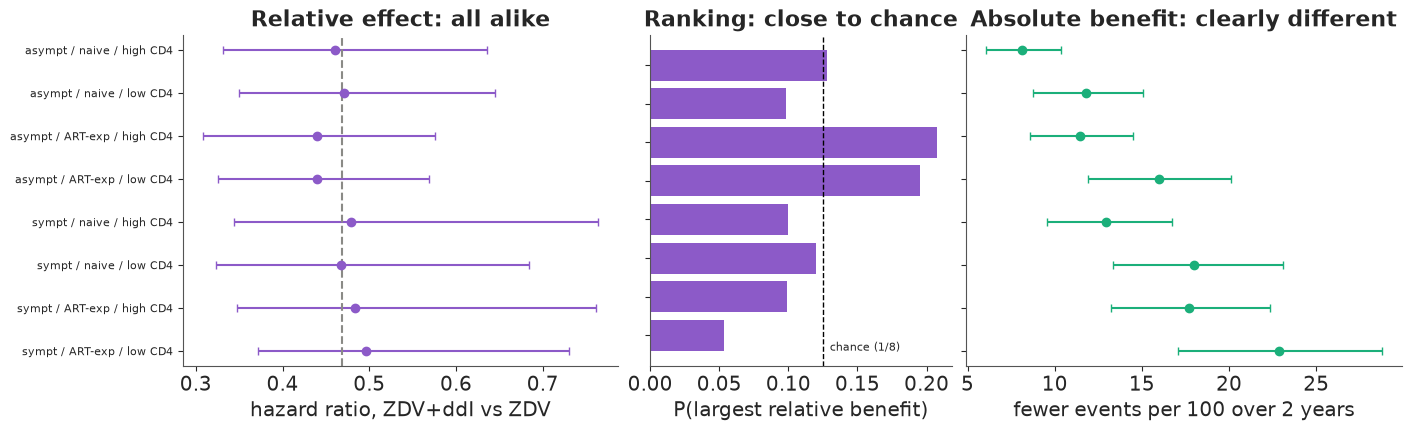

In [31]:
bt = az.extract(idata_sg, var_names=["b_trt"]).values
p_rank1 = np.bincount(np.argmin(bt, axis=0), minlength=8) / bt.shape[1]
tau_prior = prior_sg.prior["tau"].values.ravel()
tau_post = az.extract(idata_sg, var_names=["tau"]).values
print("P(subgroup has the largest relative benefit):")
print(pd.Series(p_rank1, index=GROUPS).round(2).to_string())
print("tau prior 5/50/95%:", q(tau_prior), "  posterior:", q(tau_post))

# absolute benefit per subgroup under the common-effect model (all arms' patients, standardised)
rd_group = np.array([100 * (risk_730(0, grp == g) - risk_730(1, grp == g)).mean(0) for g in range(8)])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), width_ratios=[1.3, 0.9, 1.3])
hr_q = np.exp(np.quantile(bt, [0.05, 0.5, 0.95], axis=1))
yy = np.arange(8)
axes[0].errorbar(hr_q[1], yy, xerr=[hr_q[1] - hr_q[0], hr_q[2] - hr_q[1]], fmt="o", color=PURPLE,
                 capsize=3)
axes[0].axvline(np.exp(np.median(az.extract(idata_sg, var_names=["mu_trt"]).values)), color=GREY, ls="--")
axes[0].set_yticks(yy, GROUPS, fontsize=8)
axes[0].invert_yaxis()
axes[0].set(xlabel="hazard ratio, ZDV+ddI vs ZDV", title="Relative effect: all alike")
axes[1].barh(yy, p_rank1, color=PURPLE)
axes[1].axvline(1 / 8, color="k", ls="--", lw=1)
axes[1].text(1 / 8 + 0.005, 7.4, "chance (1/8)", fontsize=8)
axes[1].set_yticks(yy, [])
axes[1].invert_yaxis()
axes[1].set(xlabel="P(largest relative benefit)", title="Ranking: close to chance")
rq = np.quantile(rd_group, [0.05, 0.5, 0.95], axis=1)
axes[2].errorbar(rq[1], yy, xerr=[rq[1] - rq[0], rq[2] - rq[1]], fmt="o", color=AQUA, capsize=3)
axes[2].set_yticks(yy, [])
axes[2].invert_yaxis()
axes[2].set(xlabel="fewer events per 100 over 2 years",
            title="Absolute benefit: clearly different");

**The question as asked (ranking relative benefit) is not supported.** Every subgroup's hazard
ratio sits near the common value, no subgroup has more than about 0.21 probability of being
"best" (chance is 0.125), and $\tau$ is shrunk towards the common effect by the hierarchy
rather than learned: its posterior is narrower than the prior but still covers both "no
heterogeneity" and "moderate heterogeneity". A table that sorted the eight point estimates
would present noise as a finding. An unpooled model (a separate effect per subgroup) would
show more spread, but with 6 to 87 events per subgroup that spread is mostly sampling noise.

The nearest question that the data **can** answer, and that serves the same decision
("whom to prioritise"): **who gains the most in absolute terms?** With a common relative effect,
absolute benefit follows baseline risk, which the data estimate well: symptomatic,
ART-experienced, low-CD4 patients gain most - the very subgroup a ranking of relative effects
would have put *last*. Say explicitly that the question was changed and
why: "we cannot tell whether ddI works *better* in any subgroup; it clearly *prevents more
events* in higher-risk patients."

In [32]:
audit += [
    dict(part="C", asked="Events avoided per 100 of our (symptomatic, ART-experienced) patients",
         answered=f"about {ans_tab.iloc[3, 1]:.0f} per 100 over 2 years "
                  f"(90%: {ans_tab.iloc[3, 0]:.0f}-{ans_tab.iloc[3, 2]:.0f})",
         why="HR (0.44) and the trial-wide risk difference (13) answer other questions",
         next_step="as asked; population standardised to the clinic's case mix"),
    dict(part="C", asked="Which newer regimen is best?",
         answered=f"ZDV+ddI, P = {p_best[0]:.2f}; all three beat ZDV alone (P ~ 1)",
         why="answered, with its uncertainty; the easier question reported separately",
         next_step="decision threshold depends on toxicity, the committee's call"),
    dict(part="C", asked="Which patients benefit most (relative effect)?",
         answered=f"not supported: P(rank 1) <= {p_rank1.max():.2f} for every subgroup "
                  "(chance: 0.125)",
         why="few events per subgroup; heterogeneity sd barely identified",
         next_step="answered instead: absolute benefit by baseline risk (well identified)"),
]

---
# The answer audit

Every question, what we could answer, and why. This table (not the parameter summaries) is
what goes to the people who asked.

In [33]:
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(audit).set_index(["part", "asked"]))

answered  \
part asked                                                                                                                                                                                  
A    Is Google or Meta more efficient?                                      not answerable from this spend history: it follows the prior (P(Google better) 0.65-1.00 across three priors)   
     (fallback) total return of paid media                                                                       depends on the baseline assumption (median 25 vs 31 customers per $1000)   
     Should the total budget go up?                                                                                   yes if a customer is worth > $62, no if < $38, undetermined between   
B    Growth in underlying demand, 2011 -> 2012                                                                                       about 1.64x (90%: 1.58-1.69); weekly exact GP agrees   
C    Events avoided per 100 of our (symptomatic, ART-experienced) patients                                                                     about 21 per 100 over 2 years (90%: 16-27)   
     Which newer regimen is best?                                                                                                     ZDV+ddI, P = 0.86; all three beat ZDV alone (P ~ 1)   
     Which patients benefit most (relative effect)?                                                                   not supported: P(rank 1) <= 0.21 for every subgroup (chance: 0.125)   

                                                                                                                                                 why  \
part asked                                                                                                                                             
A    Is Google or Meta more efficient?                                         spend on the two channels moved together; the data fix a weighted sum   
     (fallback) total return of paid media                                      slow growth and spend moved together; LOO ranks fit, not attribution   
     Should the total budget go up?                                                    the decision threshold falls outside the band for most values   
B    Growth in underlying demand, 2011 -> 2012                                             exact GP on 17k hours: weeks of computing, GBs per matrix   
C    Events avoided per 100 of our (symptomatic, ART-experienced) patients  HR (0.44) and the trial-wide risk difference (13) answer other questions   
     Which newer regimen is best?                                            answered, with its uncertainty; the easier question reported separately   
     Which patients benefit most (relative effect)?                                      few events per subgroup; heterogeneity sd barely identified   

                                                                                                                                                               next_step  
part asked                                                                                                                                                                
A    Is Google or Meta more efficient?                                      geo holdout on one channel (fake-data check: a 10%-SE test on Google makes all priors agree)  
     (fallback) total return of paid media                                                                         report both; the same experiment calibrates the total  
     Should the total budget go up?                                                                                           the brand supplies the value of a customer  
B    Growth in underlying demand, 2011 -> 2012                                                      gave up hour-level structure (not asked); HSGP checked against exact  
C    Events avoided per 100 of our (symptomatic, ART-experienced) patients      

## A checklist for when the model cannot answer

1. **Write the question contract first**: quantity, population, scale, decision. Compute that
   quantity from the posterior; do not report a parameter that is only related to it.
2. **A clean fit is not an answer.** r_hat, ESS and divergences check the sampler, not
   whether the data inform your question.
3. **Swap the prior** (or power-scale it) and see whether the answer moves. Contraction against
   a vague prior can look high for an unidentified quantity.
4. **Run a fake-data check** with a truth that would change the decision. If the correct model
   cannot recover it, improving the model will not help; different data will.
5. **Price the model before sampling**: one gradient on growing subsets, times the number of
   gradients a fit needs.
6. **Pivot in this order**: shrink the data to the question's resolution; approximate the
   model (and check the approximation where the exact model runs); add information
   (experiments, informative priors from them); shrink the question to the nearest one the
   data support, **and say that you did**.
7. **Answer the decision when you cannot answer the parameter**: find the region where every
   plausible model agrees.

## Try it yourself

1. **Design the experiment.** In the fake-data check of A6, vary the lift test's standard
   error (5%, 20%, 40%) and put it on Meta instead of Google. How precise must a test be before
   the three priors agree on the sign of the difference? What about the random-walk baseline?
2. **Ask the unpooled model.** Refit C5 with a separate treatment effect per subgroup (no
   $\tau$). How far apart are the point estimates, and how often would a ranking of them be
   reproduced in a bootstrap resample of patients?
3. **Shrink the question differently.** In part B, answer "how much did demand grow on
   working-day rush hours (7-9 am, 4-7 pm)?" Which pivot from B2 still works, and what does it
   cost to compute?